# Inflation Forecasting with LSTM (RNN)

Forecasts **1-month-ahead PCE inflation (PCEPI)** using an LSTM neural network trained on FRED-MD data.

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from fred_md_utils import (
    configure_plots, default_paths, get_splits, make_sequences,
    TEST_START, VAL_START,
)

configure_plots()
VINTAGE_DIR, RESULTS_DIR = default_paths()

# Reproducibility — must be set before any TF/Keras objects are created
tf.random.set_seed(42)
np.random.seed(42)

# ── Parameters ──────────────────────────────────────────────────────────────
SEQ_LEN       = 6    # months of history fed to the LSTM at each step
LSTM_UNITS    = 32   # hidden units in the LSTM layer
DROPOUT       = 0.3  # dropout rate on LSTM inputs
EPOCHS        = 300  # max training epochs (EarlyStopping will cut this short)
BATCH_SIZE    = 8    # small batches = more updates per epoch, better for small n
PATIENCE      = 30   # EarlyStopping patience
LEARNING_RATE = 3e-4 # lower LR reduces overshooting on small datasets
TOP_K         = 20   # SelectKBest pre-filter: keep top-K features before LSTM

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {bool(tf.config.list_physical_devices('GPU'))}")
print(f"Vintage dir        : {os.path.abspath(VINTAGE_DIR)}")


I0000 00:00:1776901164.102833  512328 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776901164.136232  512328 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776901164.809176  512328 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version : 2.21.0
GPU available      : False
Vintage dir        : /home/lukeholmes/2025-2026/ML/final-project/Macro-Econ-ML/notebooks/data


W0000 00:00:1776901165.355236  512328 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## Load & Split Data

In [2]:
# Build 2D train/val/test splits — no lag columns (n_lags=0).
# The LSTM captures temporal dependencies through sequences instead.
vintage_file, X_train, y_train, X_val, y_val, X_test, y_test, feature_names = get_splits(
    VINTAGE_DIR, horizon=1, n_lags=0,
)

print(f"\nBase features : {len(feature_names)}")
print(f"Sequence length: {SEQ_LEN} months")
print(f"Input shape will be: (batch, {SEQ_LEN}, {len(feature_names)})")


  2026-04-MD.csv: URL returned HTML — vintage not yet published
Already have 2026-03-MD.csv

Dataset summary (PCEPI first-log-diff target, 1-month-ahead):
  Train :  612 obs  1959-01-01 -> 2009-12-01
  Val   :  168 obs  2010-01-01 -> 2023-12-01
  Test  :   24 obs  2024-01-01 -> 2025-12-01
  Features: 126 (126 base × 1 time steps)

Base features : 126
Sequence length: 6 months
Input shape will be: (batch, 6, 126)


## Feature Selection & Scaling

In [3]:
from sklearn.feature_selection import SelectKBest, f_regression

# SelectKBest: reduce 130 → TOP_K features before feeding the LSTM.
# This is the single most effective regularization step for this dataset size.
selector = SelectKBest(f_regression, k=TOP_K)
selector.fit(X_train.values, y_train.values)

X_train_sel = selector.transform(X_train.values)  # (n_train, TOP_K)
X_val_sel   = selector.transform(X_val.values)    # (n_val,   TOP_K)
X_test_sel  = selector.transform(X_test.values)   # (n_test,  TOP_K)

# Track which features were kept and where PCEPI lands in the reduced set
selected_indices      = selector.get_support(indices=True)
selected_feature_names = [feature_names[i] for i in selected_indices]
pcepi_idx_sel = (selected_feature_names.index('PCEPI')
                 if 'PCEPI' in selected_feature_names else None)
print(f"Selected {TOP_K} features from {len(feature_names)}")
print(f"PCEPI in selected set: {pcepi_idx_sel is not None} "
      f"(index {pcepi_idx_sel})")

# Fit StandardScaler on training features only; transform val and test.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_val_scaled   = scaler.transform(X_val_sel)
X_test_scaled  = scaler.transform(X_test_sel)

y_train_arr = y_train.values   # raw pp — no target scaling needed with Huber loss
y_val_arr   = y_val.values     # raw pp — keeps EarlyStopping on same scale as training
y_test_arr  = y_test.values    # raw pp


Selected 20 features from 126
PCEPI in selected set: False (index None)


## Build LSTM Sequences

In [4]:
# Training sequences: straightforward — no cross-split context needed.
X_train_seq, y_train_seq = make_sequences(X_train_scaled, y_train_arr, SEQ_LEN)

# Val sequences: prepend the last (SEQ_LEN-1) training rows so the first
# val sample has a full context window.
# After prepending (SEQ_LEN-1) rows, make_sequences produces exactly len(X_val)
# sequences — one per val observation — so no further slicing is needed.
X_val_seq, y_val_seq = make_sequences(
    np.vstack([X_train_scaled[-(SEQ_LEN - 1):], X_val_scaled]),
    np.concatenate([y_train_arr[-(SEQ_LEN - 1):], y_val_arr]),
    SEQ_LEN,
)

# Test sequences: same logic, prepend last (SEQ_LEN-1) val rows.
X_test_seq, y_test_seq = make_sequences(
    np.vstack([X_val_scaled[-(SEQ_LEN - 1):], X_test_scaled]),
    np.concatenate([y_val_arr[-(SEQ_LEN - 1):], y_test_arr]),
    SEQ_LEN,
)

print(f"Train sequences : {X_train_seq.shape}  targets: {y_train_seq.shape}")
print(f"Val   sequences : {X_val_seq.shape}  targets: {y_val_seq.shape}")
print(f"Test  sequences : {X_test_seq.shape}  targets: {y_test_seq.shape}")


Train sequences : (607, 6, 20)  targets: (607,)
Val   sequences : (168, 6, 20)  targets: (168,)
Test  sequences : (24, 6, 20)  targets: (24,)


## Target Series Inspection

In [5]:
# Inspect the test-period target for anomalies (e.g., near-zero months).
# Near-zero monthly growth is real (PCE can be flat) but distorts MAPE.
target_inspect = pd.Series(y_test_arr, index=y_test.index, name='PCEPI_growth')
print("Test-period PCEPI monthly growth (log-diff × 100):")
print(target_inspect.round(4).to_string())
print(f"\nMin  : {target_inspect.min():.4f}  ({target_inspect.idxmin().date()})")
print(f"Max  : {target_inspect.max():.4f}  ({target_inspect.idxmax().date()})")
print(f"Near-zero months (|value| < 0.05): "
      f"{list(target_inspect[target_inspect.abs() < 0.05].index.strftime('%Y-%m'))}")
print(f"\nNote: near-zero actuals are real data, not errors — PCE was genuinely "
      f"flat those months. They inflate MAPE and should be interpreted cautiously.")


Test-period PCEPI monthly growth (log-diff × 100):
date
2024-01-01    0.3006
2024-02-01    0.3583
2024-03-01    0.2460
2024-04-01    0.0057
2024-05-01    0.1547
2024-06-01    0.1593
2024-07-01    0.1236
2024-08-01    0.2217
2024-09-01    0.2654
2024-10-01    0.1148
2024-11-01    0.2740
2024-12-01    0.3498
2025-01-01    0.4011
2025-02-01    0.0159
2025-03-01    0.1658
2025-04-01    0.1822
2025-05-01    0.2868
2025-06-01    0.1711
2025-07-01    0.2619
2025-08-01    0.2605
2025-09-01    0.1941
2025-10-01    0.2203
2025-11-01    0.3583
2025-12-01    0.2749

Min  : 0.0057  (2024-04-01)
Max  : 0.4011  (2025-01-01)
Near-zero months (|value| < 0.05): ['2024-04', '2025-02']

Note: near-zero actuals are real data, not errors — PCE was genuinely flat those months. They inflate MAPE and should be interpreted cautiously.


## Define RNNForecaster

In [6]:
class RNNForecaster:
    """
    LSTM-based inflation forecaster.

    Accepts 3-D input (batch, seq_len, n_features) produced by make_sequences().
    Exposes the same evaluate() interface as InflationForecaster so metrics are
    directly comparable across notebooks.
    """

    def __init__(self, seq_len, n_features,
                 units=LSTM_UNITS, dropout=DROPOUT, lr=LEARNING_RATE):
        self.seq_len    = seq_len
        self.n_features = n_features
        self.units      = units
        self.dropout    = dropout
        self.lr         = lr
        self.model      = self._build_model()
        self.history    = None

    def _build_model(self):
        model = keras.Sequential([
            keras.layers.Input(shape=(self.seq_len, self.n_features)),
            keras.layers.LSTM(
                self.units,
                dropout=self.dropout,
                recurrent_dropout=0.1,
                kernel_regularizer=keras.regularizers.l2(1e-4),
                recurrent_regularizer=keras.regularizers.l2(1e-4),
            ),
            keras.layers.Dense(1),   # no hidden layer — avoids extra params
        ])
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=self.lr),
            # Huber loss: quadratic for small errors, linear for large ones.
            # Avoids MSE's tendency to shrink predictions toward the mean,
            # which causes the "muted magnitude" symptom on volatile months.
            loss=keras.losses.Huber(delta=0.5),
        )
        return model

    def train(self, X_train_seq, y_train_seq,
              X_val_seq, y_val_seq,
              epochs=EPOCHS, batch_size=BATCH_SIZE, patience=PATIENCE):
        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=patience,
            restore_best_weights=True,
            verbose=1,
        )
        reduce_lr = keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=PATIENCE,
            min_lr=1e-5, verbose=1,
        )
        self.history = self.model.fit(
            X_train_seq, y_train_seq,
            validation_data=(X_val_seq, y_val_seq),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[early_stop, reduce_lr],
            verbose=1,
        )
        return self

    def predict(self, X_seq):
        """Accept 3-D input (n_samples, seq_len, n_features), return 1-D raw predictions
        in original pp units (no inverse-transform needed — model trained on raw targets)."""
        return self.model.predict(X_seq, verbose=0).flatten()

    def evaluate(self, X_seq, y_true):
        """
        Returns (metrics_dict, y_pred).
        Metric names and scale are identical to InflationForecaster.evaluate().
        """
        y_pred = self.predict(X_seq)
        y_true = np.asarray(y_true)
        metrics = {
            'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
            'mae':  float(mean_absolute_error(y_true, y_pred)),
            'r2':   float(r2_score(y_true, y_pred)),
            'mape': float(np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100),
        }
        return metrics, y_pred

forecaster = RNNForecaster(
    seq_len=SEQ_LEN,
    n_features=TOP_K,
    units=LSTM_UNITS,
    dropout=DROPOUT,
    lr=LEARNING_RATE,
)
forecaster.model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         6,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,817 (26.63 KB)

 Trainable params: 6,817 (26.63 KB)

 Non-trainable params: 0 (0.00 B)

## Train

In [7]:
forecaster.train(
    X_train_seq, y_train_seq,
    X_val_seq,   y_val_seq,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    patience=PATIENCE,
)


Epoch 1/300
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2708 - val_loss: 0.1810 - learning_rate: 3.0000e-04
Epoch 2/300
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2193 - val_loss: 0.1675 - learning_rate: 3.0000e-04
Epoch 3/300
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1973 - val_loss: 0.1704 - learning_rate: 3.0000e-04
Epoch 4/300
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1857 - val_loss: 0.1704 - learning_rate: 3.0000e-04
Epoch 5/300
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1766 - val_loss: 0.1711 - learning_rate: 3.0000e-04
Epoch 6/300
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1724 - val_loss: 0.1700 - learning_rate: 3.0000e-04
Epoch 7/300
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1759 - val_loss: 0.1709 - learning_rate: 3.0000e-04
Epoch 8/300
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1676 - val_loss: 0.1705 - learning_rate: 3.0000e-04
Epoch 9/300
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1663 - val_loss: 0.1709 - learning_

## Training & Validation Loss

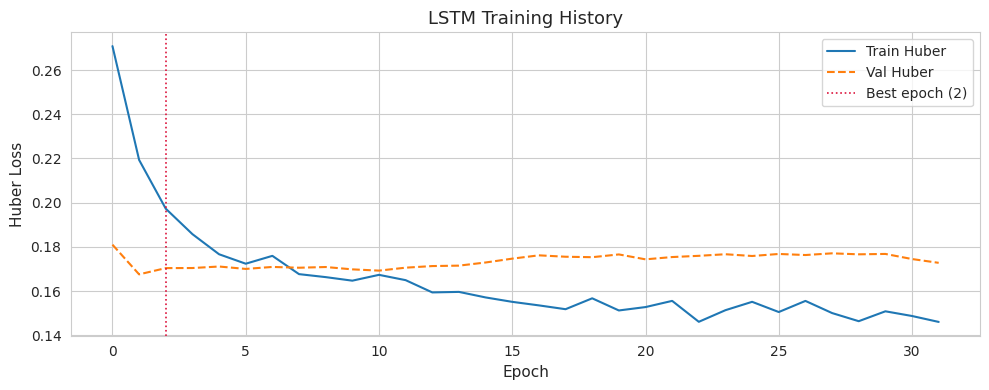

Best epoch    : 2
Best val loss : 0.167547  |  Train loss at best epoch: 0.219333
Overfit ratio (val/train): 0.76  ← healthy


In [8]:
hist = forecaster.history.history
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hist['loss'],     label='Train Huber', linewidth=1.5)
ax.plot(hist['val_loss'], label='Val Huber',   linewidth=1.5, linestyle='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('Huber Loss')
ax.set_title('LSTM Training History')
best_epoch = int(np.argmin(hist['val_loss'])) + 1
ax.axvline(best_epoch, color='crimson', linestyle=':', linewidth=1.2,
           label=f'Best epoch ({best_epoch})')
ax.legend()
fig.tight_layout()
plt.show()

best_train = hist['loss'][best_epoch - 1]
best_val   = hist['val_loss'][best_epoch - 1]
overfit_ratio = best_val / best_train if best_train > 0 else float('nan')
print(f"Best epoch    : {best_epoch}")
print(f"Best val loss : {best_val:.6f}  |  Train loss at best epoch: {best_train:.6f}")
print(f"Overfit ratio (val/train): {overfit_ratio:.2f}  "
      f"{'← severe overfit' if overfit_ratio > 3 else '← moderate' if overfit_ratio > 1.5 else '← healthy'}")


## Evaluate on Test Set

In [9]:
test_metrics, y_test_pred = forecaster.evaluate(X_test_seq, y_test_seq)

print("Out-of-Sample Test Performance (LSTM):")
print(f"  Test date range : {y_test.index.min().date()} to {y_test.index.max().date()}")
print(f"  n observations  : {len(y_test_seq)}")
print(f"  RMSE : {test_metrics['rmse']:.4f}")
print(f"  MAE  : {test_metrics['mae']:.4f}")
print(f"  R\u00b2   : {test_metrics['r2']:.4f}")
print(f"  MAPE : {test_metrics['mape']:.2f}%")
print()
print("Metric scale: monthly log-diff \u00d7 100 (percentage points of monthly PCE inflation)")


Out-of-Sample Test Performance (LSTM):
  Test date range : 2024-01-01 to 2025-12-01
  n observations  : 24
  RMSE : 0.1007
  MAE  : 0.0824
  R²   : -0.0413
  MAPE : 245.19%

Metric scale: monthly log-diff × 100 (percentage points of monthly PCE inflation)


## Validation Fit

Validation Performance (LSTM):
  Val date range : 2010-01-01 to 2023-12-01
  n observations : 168
  RMSE : 0.1772
  MAE  : 0.1296
  R²   : 0.2268


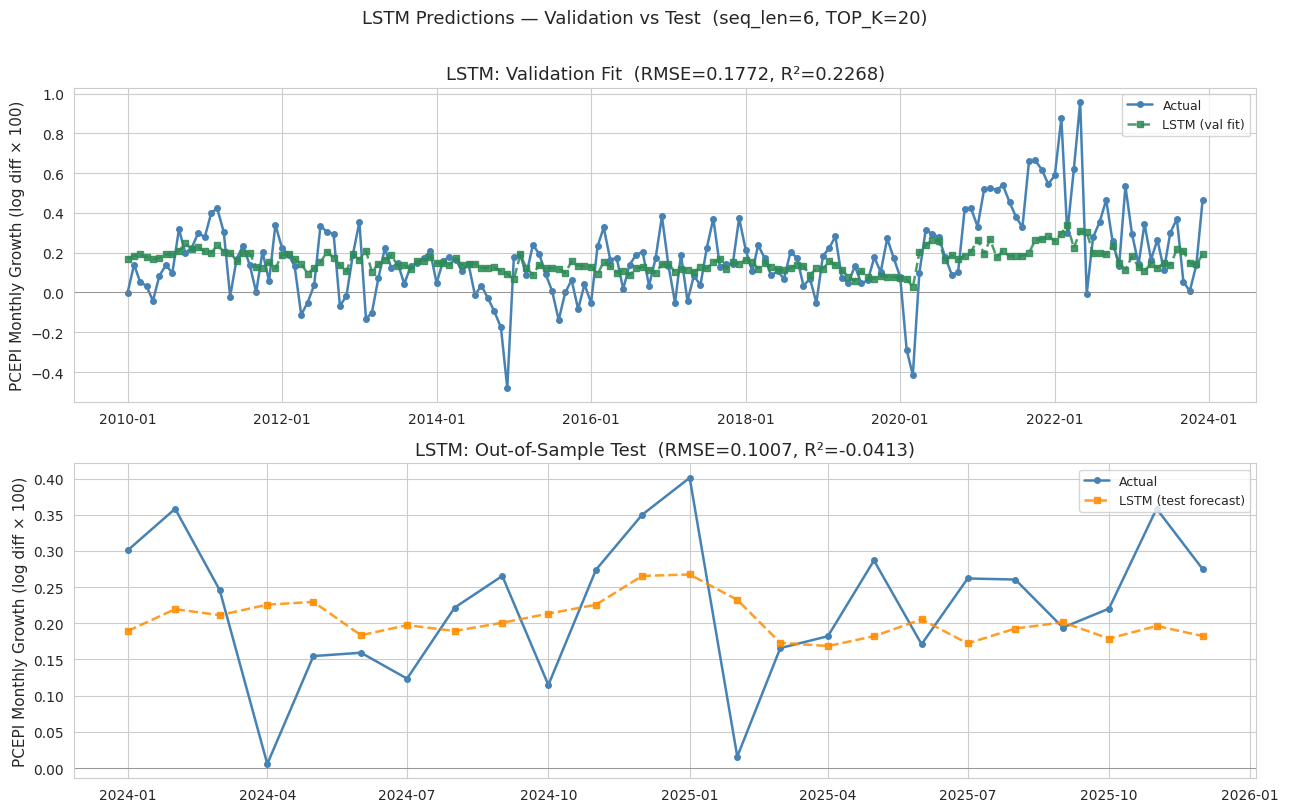

In [10]:
# Evaluate on validation set to visualise in-sample fit before the test period.
# All targets are now raw pp (no y_scaler), so val and test metrics are on the same scale.
val_metrics, y_val_pred = forecaster.evaluate(X_val_seq, y_val.values)

print("Validation Performance (LSTM):")
print(f"  Val date range : {y_val.index.min().date()} to {y_val.index.max().date()}")
print(f"  n observations : {len(y_val.values)}")
print(f"  RMSE : {val_metrics['rmse']:.4f}")
print(f"  MAE  : {val_metrics['mae']:.4f}")
print(f"  R²   : {val_metrics['r2']:.4f}")

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=False)

# --- Validation panel (raw scale) ---
ax = axes[0]
ax.plot(y_val.index, y_val.values, 'o-', label='Actual',          linewidth=1.8, markersize=4, color='steelblue')
ax.plot(y_val.index, y_val_pred,   's--', label='LSTM (val fit)', linewidth=1.8, markersize=4, color='seagreen', alpha=0.85)
ax.axhline(0, color='grey', linewidth=0.5)
ax.set_title(f'LSTM: Validation Fit  (RMSE={val_metrics["rmse"]:.4f}, R²={val_metrics["r2"]:.4f})')
ax.set_ylabel('PCEPI Monthly Growth (log diff × 100)')
ax.legend(loc='upper right', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# --- Test panel (raw scale) ---
ax = axes[1]
ax.plot(y_test.index, y_test_seq,  'o-', label='Actual',               linewidth=1.8, markersize=4, color='steelblue')
ax.plot(y_test.index, y_test_pred, 's--', label='LSTM (test forecast)', linewidth=1.8, markersize=4, color='darkorange', alpha=0.85)
ax.axhline(0, color='grey', linewidth=0.5)
ax.set_title(f'LSTM: Out-of-Sample Test  (RMSE={test_metrics["rmse"]:.4f}, R²={test_metrics["r2"]:.4f})')
ax.set_ylabel('PCEPI Monthly Growth (log diff × 100)')
ax.legend(loc='upper right', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

fig.suptitle(f'LSTM Predictions — Validation vs Test  (seq_len={SEQ_LEN}, TOP_K={TOP_K})',
             fontsize=13, y=1.01)
fig.tight_layout()
plt.show()


## Data-Anchored & Chained Forecasts

In [11]:
import datetime
from dateutil.relativedelta import relativedelta
from fred_md_utils import load_fred_md_file, load_fred_md_raw

# --- Load full transformed vintage for anchor lookups ---
df_feat, _ = load_fred_md_file(vintage_file)
df_feat = df_feat.ffill().bfill()

TARGET_FEATURE   = 'PCEPI'
anchor_date      = df_feat.index.max()
current_month    = pd.Timestamp(datetime.date.today().replace(day=1))
chain_start_date = y_test.index.max()   # last test observation

total_forecast_steps = (
    (current_month.year  - chain_start_date.year)  * 12 +
    (current_month.month - chain_start_date.month)
)

print(f"Vintage anchor      : {anchor_date.date()}")
print(f"Chain start         : {chain_start_date.date()}")
print(f"Current month       : {current_month.date()}")
print(f"Total forecast steps: {total_forecast_steps}")

# --- Train medians as fallback for NaN-filled vintage rows ---
train_medians = X_train.median()

# --- Initialize buffer: last SEQ_LEN unscaled rows up to chain_start_date ---
# Combine val + test unscaled features; take last SEQ_LEN rows (ending at chain_start_date).
X_hist_unscaled = np.vstack([X_val_sel, X_test_sel])
buffer_unscaled  = X_hist_unscaled[-SEQ_LEN:].copy()   # (SEQ_LEN, n_features)

# PCEPI monthly growth from vintage (for YoY calculation and anchored updates)
# Load raw levels to compute PCEPI growth as first log-diff × 100 (tcode 5),
# matching the training target — FRED-MD native tcode for PCEPI is 6 (second diff).
df_raw_vintage, _ = load_fred_md_raw(vintage_file)
pcepi_growth = (np.log(df_raw_vintage['PCEPI']).diff() * 100).ffill().bfill()

# --- Forecast loop ---
forecast_rows = []

for step in range(1, total_forecast_steps + 1):
    # Scale buffer at prediction time, reshape, and predict
    buf_scaled = scaler.transform(buffer_unscaled)                 # (SEQ_LEN, TOP_K)
    X_seq      = buf_scaled.reshape(1, SEQ_LEN, TOP_K)
    pred       = float(forecaster.predict(X_seq)[0])

    forecast_date = chain_start_date + pd.DateOffset(months=step)
    is_anchored   = forecast_date in df_feat.index

    # YoY: rolling 12-month sum of monthly log-diffs
    prior_preds     = {r['date']: r['forecast'] for r in forecast_rows}
    monthly_growths = []
    for i in range(12):
        month = forecast_date - pd.DateOffset(months=11 - i)
        if month == forecast_date:
            monthly_growths.append(pred)
        elif month in pcepi_growth.index and pd.notna(pcepi_growth.loc[month]):
            monthly_growths.append(float(pcepi_growth.loc[month]))
        elif month in prior_preds:
            monthly_growths.append(prior_preds[month])
        else:
            monthly_growths = None
            break
    yoy = sum(monthly_growths) if monthly_growths is not None else float('nan')

    forecast_rows.append({
        'step':             step,
        'date':             forecast_date,
        'forecast':         pred,
        'annualized_naive': pred * 12,
        'yoy_equivalent':   yoy,
        'anchored':         is_anchored,
    })

    # Update buffer: use actual vintage row if available, else chain PCEPI from pred
    if is_anchored:
        raw_row = (df_feat.reindex(columns=feature_names)
                          .loc[forecast_date]
                          .fillna(train_medians)
                          .values.reshape(1, -1))
        new_row = selector.transform(raw_row).flatten()
    else:
        new_row = buffer_unscaled[-1].copy()
        if pcepi_idx_sel is not None:
            new_row[pcepi_idx_sel] = pred   # advance PCEPI to predicted monthly growth

    buffer_unscaled = np.vstack([buffer_unscaled[1:], new_row.reshape(1, -1)])

forecast_df = pd.DataFrame(forecast_rows)

# Print results table
print(f"\n{'='*70}")
print('  LATEST FORECASTS (LSTM)')
print(f"  Vintage anchor: {anchor_date.date()}  |  Chain start: {chain_start_date.date()}")
for row in forecast_rows:
    month_label = row['date'].strftime('%b %Y')
    tag     = '(data-anchored)' if row['anchored'] else '(chained)     '
    yoy_str = (f"{row['yoy_equivalent']:+.2f}% YoY"
               if not np.isnan(row['yoy_equivalent']) else 'YoY: N/A')
    print(f"  {month_label} (step {row['step']:2d}) {tag}: "
          f"{row['forecast']:+.4f}% monthly  ({yoy_str})")
print(f"{'='*70}")


Vintage anchor      : 2026-02-01
Chain start         : 2025-12-01
Current month       : 2026-04-01
Total forecast steps: 4

  LATEST FORECASTS (LSTM)
  Vintage anchor: 2026-02-01  |  Chain start: 2025-12-01
  Jan 2026 (step  1) (data-anchored): +0.1825% monthly  (+2.70% YoY)
  Feb 2026 (step  2) (data-anchored): +0.1717% monthly  (+2.56% YoY)
  Mar 2026 (step  3) (chained)     : +0.1553% monthly  (+2.81% YoY)
  Apr 2026 (step  4) (chained)     : +0.1423% monthly  (+2.78% YoY)


## Forecast Plot

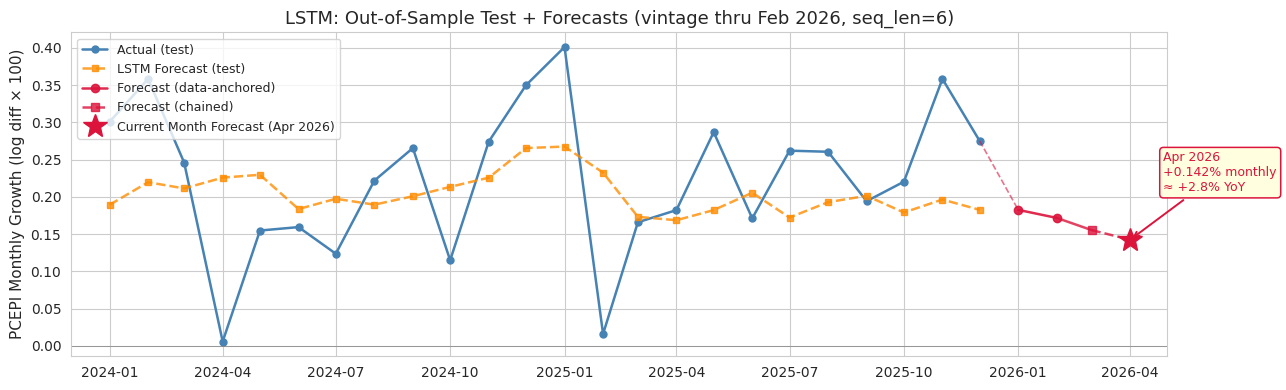

In [12]:
fig, ax = plt.subplots(figsize=(13, 4))

# Test actuals + LSTM test predictions
ax.plot(y_test.index, y_test.values, 'o-', label='Actual (test)',
        linewidth=1.8, markersize=5, color='steelblue')
ax.plot(y_test.index, y_test_pred,   's--', label='LSTM Forecast (test)',
        linewidth=1.8, alpha=0.8, markersize=5, color='darkorange')

# Connector from last test obs to first forecast step
ax.plot([y_test.index[-1], forecast_df.iloc[0]['date']],
        [y_test.values[-1], forecast_df.iloc[0]['forecast']],
        '--', color='crimson', linewidth=1.2, alpha=0.6)

# Data-anchored vs chained forecast segments
anchored_df = forecast_df[forecast_df['anchored']]
chained_df  = forecast_df[~forecast_df['anchored']]

if not anchored_df.empty:
    ax.plot(anchored_df['date'], anchored_df['forecast'],
            'o-', color='crimson', linewidth=1.8, alpha=0.9, markersize=6,
            label='Forecast (data-anchored)')
if not chained_df.empty:
    ax.plot(chained_df['date'], chained_df['forecast'],
            's--', color='crimson', linewidth=1.8, alpha=0.8, markersize=6,
            label='Forecast (chained)')
if not anchored_df.empty and not chained_df.empty:
    ax.plot([anchored_df.iloc[-1]['date'], chained_df.iloc[0]['date']],
            [anchored_df.iloc[-1]['forecast'], chained_df.iloc[0]['forecast']],
            '-', color='crimson', linewidth=1.8, alpha=0.8)

# Star on current-month forecast
last_row  = forecast_df.iloc[-1]
yoy_label = (f"\u2248 {last_row['yoy_equivalent']:+.1f}% YoY"
             if not np.isnan(last_row['yoy_equivalent']) else '')
ax.plot(last_row['date'], last_row['forecast'],
        '*', color='crimson', markersize=18, zorder=5,
        label=f"Current Month Forecast ({last_row['date'].strftime('%b %Y')})")
ax.annotate(
    f"{last_row['date'].strftime('%b %Y')}\n{last_row['forecast']:+.3f}% monthly\n{yoy_label}",
    xy=(last_row['date'], last_row['forecast']),
    xytext=(24, 35), textcoords='offset points', fontsize=9, color='crimson',
    arrowprops=dict(arrowstyle='->', color='crimson', lw=1.4),
    bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='crimson', lw=1.1),
)

ax.axhline(0, color='grey', linewidth=0.5)
ax.set_title(f'LSTM: Out-of-Sample Test + Forecasts '
             f'(vintage thru {anchor_date.strftime("%b %Y")}, seq_len={SEQ_LEN})')
ax.set_ylabel('PCEPI Monthly Growth (log diff \u00d7 100)')
ax.legend(loc='upper left', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.set_xlim(left=y_test.index.min() - pd.DateOffset(months=1),
            right=forecast_df['date'].max() + pd.DateOffset(months=1))
fig.tight_layout()
plt.show()


## Save Predictions for Model Comparison

In [13]:
# Save test predictions and aligned dates for model_comparison.ipynb.
os.makedirs('results', exist_ok=True)

test_dates_seq = y_test.index   # fully aligned — one prediction per test obs

np.save('results/rnn_preds.npy',       y_test_pred)
np.save('results/rnn_dates.npy',       np.array(test_dates_seq, dtype='datetime64[ns]'))
np.save('results/rnn_actuals.npy',     y_test.values)  # raw pp, not z-scored

print(f"Saved {len(y_test_pred)} test predictions to results/")
print(f"  Date range: {test_dates_seq.min().date()} to {test_dates_seq.max().date()}")


Saved 24 test predictions to results/
  Date range: 2024-01-01 to 2025-12-01
